Estudiante: Yessika Loyo


In [5]:
pip install pandas, numpy, matplotlib, seaborn, scikit-learn, jupyterlab, plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: 'pandas,': Expected semicolon (after name with no version specifier) or end
    pandas,
          ^


In [7]:
%pip install pandas

  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl (9.9 MB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------- ----------------- 7.1/12.6 MB 34.4 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.6 MB 36.5 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 26.2 MB/s  0:00:00

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tz


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Importar la librería Pandas
import pandas as pd

# Etapa 1: Recopilación y Preparación de Datos

### 1_1- Cargar los set de datos como Dataframes

In [9]:
def cargar_dataset(link):
  # Usamos regex para extraer el file_id del link
  file_id = link.split('/d/')[1].split('/')[0]

  # Con ese file_id generamos la url
  url = f"https://drive.google.com/uc?id={file_id}"

  # Finalmente lo importamos usando el método read_csv() con la url generada
  df = pd.read_csv(url)
  return df

### dataset clientes

In [ ]:
# Link generado al compartir el archivo clientes.csv
link = "https://drive.google.com/file/d/12zKI6H7-F5IrGVMWtuxPmFeo0-95vrUI/view?usp=drive_link"
df_cli = cargar_dataset(link)
df_cli.head(2)

,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04


### dataset ventas

In [ ]:
# Link generado al compartir el archivo ventas.csv
link = "https://drive.google.com/file/d/1PF32QOKYCYxvl_61Va-oMC5qMEPVCi07/view?usp=sharing"
df_ven = cargar_dataset(link)
# df_ven[df_ven['producto'] == "Adorno de pared"].head(2)
df_ven.head(2)

,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración


### dataset marketing

In [ ]:
# Link generado al compartir el archivo marketing.csv
link = "https://drive.google.com/file/d/1z1APWn1d5_FNiCxriyGo5PLlTdafCI9b/view?usp=sharing"
df_mar = cargar_dataset(link)
df_mar.head(2)

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024


#### <font color="red">📌 Documentación:</font>  
<font color="red">En esta primera parte se cargaron los set de datos como Dataframe, se cargaron cada uno de los documentos clientes, ventas y marketing, para poder analizarlos en el Colab </font>

## 1_4- Análisis exploratorio inicial de los DataFrames.

Generamos una función con los métodos que deseamos incluir en el EDA Inicial

In [ ]:
df_mar.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
85,False
86,False
87,False
88,False


In [ ]:
def resumen_eda(df):
    print("📊 Dimensiones del dataset")
    print(f"Filas: {df.shape[0]}")
    print(f"Columnas: {df.shape[1]}")
    print("-" * 40)

    print("\n🔎 Tipos de datos")
    print(df.dtypes)
    print("-" * 40)

    print("\n🔎 Primeros registros")
    print(df.head(2))
    print("-" * 40)

    print("\n📈 Estadísticas descriptivas")
    print(df.describe(include='number'))
    print("-" * 40)

    print("\n📈 Estadísticas descriptivas")
    try:
        print(df.describe(include='object'))
    except:
      print("No hay variables categóricas")
    print("-" * 40)

    print("\n⚠️ Valores nulos por columna")
    nulos = df.isnull().sum()
    if (nulos > 0).any():
        print(nulos[nulos > 0].sort_values(ascending=False))
    else:
        print("No hay valores nulos en el DataFrame (0 en todas las columnas)")
    print("-" * 40)

    print("\n📌 Porcentaje de nulos por columna")
    porcentaje_nulos = df.isnull().mean() * 100
    if (porcentaje_nulos > 0).any():
        print(porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False))
    else:
        print("No hay valores nulos (0% en todas las columnas)")
    print("-" * 40)

    print("\n🔁 Registros duplicados")
    duplicados = df.duplicated().sum()
    print(f"Cantidad de duplicados: {duplicados}")
    print("-" * 40)



#### <font color="red">📌 Documentación:</font>  
<font color="red">Para realizar el Análisis Exploratorio Inicial (EDA), se genero una función `resumen_eda(df)` con los métodos que deseamos incluir en el EDA inicial, tales como: dimensiones del dataset, tipos de datos, primeros registros, estadísticas descriptivas, registros duplicados y valores nulos, este análisis inicial nos permitira normalizar los datos para su posterior análisis </font>

## 1_5- Calidad de Datos

En esta sección usamos la función definida en el item 1_4, aplicada a cada dataframe, y documentamos las acciones para limpiar y transformar nuestros datos

### EDA clientes

In [ ]:
# Invocar a la funcion y pasarle el dataframe clientes
resumen_eda(df_cli)

📊 Dimensiones del dataset
Filas: 567
Columnas: 5
----------------------------------------

🔎 Tipos de datos
id_cliente      int64
nombre         object
edad            int64
ciudad         object
ingresos      float64
dtype: object
----------------------------------------

🔎 Primeros registros
   id_cliente               nombre  edad         ciudad  ingresos
0           1      Aloysia Screase    44  Mar del Plata  42294.68
1           2  Kristina Scaplehorn    25        Posadas  24735.04
----------------------------------------

📈 Estadísticas descriptivas
       id_cliente        edad      ingresos
count  567.000000  567.000000    567.000000
mean   284.000000   37.940035  34668.739012
std    163.823075   10.202885  12974.531446
min      1.000000   20.000000    170.290000
25%    142.500000   30.000000  26015.240000
50%    284.000000   37.000000  35066.830000
75%    425.500000   43.000000  42457.100000
max    567.000000   81.000000  88053.010000
----------------------------------------


#### <font color="red">📌 Documentación:</font>  
<font color="red">*EDA Clientes*, el dataset presenta una estructura consistente con 567 registros y 5 variables, incluyendo datos numéricos y categóricos. No se identifican valores nulos ni registros duplicados, lo que indica una buena calidad inicial de los datos. Las variables numéricas muestran una distribución razonable. En general, el dataset se encuentra en condiciones adecuadas para su análisis e integración con otras fuentes. </font>

### EDA ventas

In [ ]:
resumen_eda(df_ven)

📊 Dimensiones del dataset
Filas: 3035
Columnas: 6
----------------------------------------

🔎 Tipos de datos
id_venta         int64
producto        object
precio          object
cantidad       float64
fecha_venta     object
categoria       object
dtype: object
----------------------------------------

🔎 Primeros registros
   id_venta           producto   precio  cantidad fecha_venta   categoria
0       792  Cuadro decorativo   $69.94       5.0  02/01/2024  Decoración
1       811    Lámpara de mesa  $105.10       5.0  02/01/2024  Decoración
----------------------------------------

📈 Estadísticas descriptivas
          id_venta     cantidad
count  3035.000000  3033.000000
mean   1499.851400     6.496538
std     866.465379     3.457250
min       1.000000     1.000000
25%     748.500000     3.000000
50%    1502.000000     7.000000
75%    2249.500000     9.000000
max    3000.000000    12.000000
----------------------------------------

📈 Estadísticas descriptivas
               producto  p

#### <font color="red">📌 Documentación:</font>  
<font color="red">*EDA Ventas*, El dataset de ventas contiene 3035 registros y 6 variables, incluyendo información sobre productos, precios, cantidades y fechas de venta. Se observa que algunas columnas presentan tipos de datos no adecuados para el análisis, como precio y fecha_venta, que se encuentran en formato texto y requerirán transformación a variables numéricas y de fecha respectivamente. También se identifican valores nulos en las variables precio y cantidad, aunque en un porcentaje muy bajo, lo que permite su tratamiento sin afectar significativamente el análisis. Asimismo, se detectan 35 registros duplicados que deberán ser eliminados para evitar distorsiones en los resultados. Desde el punto de vista descriptivo, la cantidad de productos vendidos presenta cierta variabilidad, con un promedio de aproximadamente 6 unidades por venta. Además, se cuenta con 30 productos distintos distribuidos en 3 categorías, siendo "Decoración" la más frecuente. El dataset requiere una etapa de limpieza y transformación antes de avanzar hacia análisis más profundos o integraciones con otras fuentes de datos. </font>

### EDA marketing

In [ ]:
resumen_eda(df_mar)

📊 Dimensiones del dataset
Filas: 90
Columnas: 6
----------------------------------------

🔎 Tipos de datos
id_campanha       int64
producto         object
canal            object
costo           float64
fecha_inicio     object
fecha_fin        object
dtype: object
----------------------------------------

🔎 Primeros registros
   id_campanha         producto canal  costo fecha_inicio   fecha_fin
0           74  Adorno de pared    TV   4.81   20/03/2024  03/05/2024
1           12           Tablet  RRSS   3.40   26/03/2024  13/05/2024
----------------------------------------

📈 Estadísticas descriptivas
       id_campanha      costo
count    90.000000  90.000000
mean     45.500000   4.928667
std      26.124701   0.947750
min       1.000000   2.950000
25%      23.250000   4.372500
50%      45.500000   4.900000
75%      67.750000   5.562500
max      90.000000   7.390000
----------------------------------------

📈 Estadísticas descriptivas
               producto canal fecha_inicio   fecha_f

#### <font color="red">📌 Documentación:</font>  
<font color="red">*EDA Marketing*, El dataset de marketing contiene 90 registros y 6 variables, incluyendo información sobre `campañas`, `productos`, `canal`, `costos` y `fechas_inicio` y `fecha_fin`. Se observa que las variables fecha_inicio y fecha_fin se encuentran en formato texto, por lo que será necesario convertirlas a tipo fecha para facilitar su análisis.El dataset no presenta valores nulos ni registros duplicados, lo que indica una buena consistencia y confiabilidad inicial de la información. Desde el punto de vista descriptivo, se identifican 30 productos distintos promocionados a través de 3 canales (TV, RRSS y Email), con una distribución relativamente equilibrada entre ellos. El costo de las campañas presenta baja dispersión, con un promedio cercano a 4.93, lo que sugiere una inversión homogénea entre campañas. En general, el dataset se encuentra en buen estado y requiere únicamente transformaciones en las variables de fecha para poder avanzar con análisis más avanzados e integraciones con datos de ventas. </font>

# Etapa 2: Preprocesamiento y Limpieza de Datos

## 2_1- Limpieza de Datos:

En esta sección debemos dejar los dataframes normalizados y libres de registros duplicados y de valores nulos.

### PREP clientes

**Acciones en clientes:**
* Títulos de columna: Nada
* Tipos de datos: Nada
* Registros duplicados: Nada
* Valores nulos: Nada

#### <font color="red">📌 Documentación:</font>  
<font color="red">*PREP Clientes*, el dataset se encuentra en condiciones adecuadas para su análisis e integración con otras fuentes. </font>

### PREP ventas

**Acciones en ventas:**

Títulos de columna:
Nada

Tipos de datos:
* precio: remover el $ usando el método replace()
* precio: pasar de object a float
* fecha_venta: pasar de object a datetime
* cantidad: pasar a int

Registros duplicados:
remover 35

Valores nulos:
precio: 2
cantidad: 2

#### <font color="red">📌 Documentación:</font>  
<font color="red">*PREP Ventas*, Se realizó la limpieza de los registros duplicados y valores nulos y se transformaron los datos `precio`, `fecha de venta` y `cantidad` antes de avanzar hacia análisis más profundos o integraciones con otras fuentes de datos. </font>

In [ ]:
# hacer una copia
df_ven_pp = df_ven.copy()

In [ ]:
# remover $ del precio
df_ven_pp['precio'] = df_ven_pp['precio'].str.replace('$', '')
df_ven_pp.head(2)

,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,105.10,5.0,02/01/2024,Decoración


In [ ]:
# convertir precio de object a float
df_ven_pp['precio'] = pd.to_numeric(df_ven_pp['precio'], errors="coerce")
df_ven_pp["precio"].isnull().sum()

np.int64(2)

In [ ]:
df_ven_pp.dtypes['precio']

dtype('float64')

In [ ]:
# convertir fecha_venta de object a datetime
# df_ven_pp['fecha_venta'] = pd.to_datetime(df_ven_pp['fecha_venta'], dayfirst=True, errors='coerce')
df_ven_pp['fecha_venta'] = pd.to_datetime(df_ven_pp['fecha_venta'], format='%d/%m/%Y', errors='coerce')

In [ ]:
df_ven_pp.duplicated().sum()

np.int64(35)

In [ ]:
df_ven_pp.duplicated(keep=False)

,0
0,False
1,False
2,False
3,False
4,False
...,...
3030,False
3031,False
3032,False
3033,False


In [ ]:
# visualizar duplicados
df_ven_pp[df_ven_pp.duplicated(keep=False)].sort_values(by='id_venta')

,id_venta,producto,precio,cantidad,fecha_venta,categoria
820,56,Cortinas,66.24,5.0,2024-04-05,Decoración
826,56,Cortinas,66.24,5.0,2024-04-05,Decoración
832,145,Alfombra,41.72,8.0,2024-04-06,Decoración
844,145,Alfombra,41.72,8.0,2024-04-06,Decoración
878,204,Jarrón decorativo,94.75,1.0,2024-04-08,Decoración
...,...,...,...,...,...,...
830,2545,Auriculares,32.81,11.0,2024-04-05,Electrónica
883,2705,Auriculares,87.29,2.0,2024-04-08,Electrónica
889,2705,Auriculares,87.29,2.0,2024-04-08,Electrónica
831,2778,SmartWatch,70.66,7.0,2024-04-05,Electrónica


In [ ]:
# eliminar duplicados
# df_ven_pp = df_ven_pp.drop_duplicates()
df_ven_pp.drop_duplicates(inplace=True)

In [ ]:
# visualizar los registros con valores nulos
df_ven_pp[df_ven_pp['precio'].isnull() | df_ven_pp['cantidad'].isnull()]

,id_venta,producto,precio,cantidad,fecha_venta,categoria
136,627,Elementos de cerámica,NaN,NaN,2024-01-17,Decoración
139,2171,Parlantes Bluetooth,NaN,NaN,2024-01-17,Electrónica


In [ ]:
# eliminamos valores NaN
df_ven_pp = df_ven_pp.dropna()
# df_ven_pp.dropna(implace=True)
# df_ven_pp = df_ven_pp.dropna(subset=['precio','cantidad'])


In [ ]:
# transformación de la cantidad en int
df_ven_pp['cantidad'] = pd.to_numeric(df_ven_pp['cantidad'], errors='coerce')
df_ven_pp['cantidad'] = df_ven_pp['cantidad'].fillna(0)
df_ven_pp['cantidad'] = df_ven_pp['cantidad'].astype(int)

df_ven_pp['cantidad'] = pd.to_numeric(df_ven_pp['cantidad'], errors='coerce').fillna(0).astype(int)
df_ven_pp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venta     2998 non-null   int64         
 1   producto     2998 non-null   object        
 2   precio       2998 non-null   float64       
 3   cantidad     2998 non-null   int64         
 4   fecha_venta  2998 non-null   datetime64[ns]
 5   categoria    2998 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 164.0+ KB


In [ ]:
df_ven_pp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venta     2998 non-null   int64         
 1   producto     2998 non-null   object        
 2   precio       2998 non-null   float64       
 3   cantidad     2998 non-null   int64         
 4   fecha_venta  2998 non-null   datetime64[ns]
 5   categoria    2998 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 164.0+ KB


### PREP marketing

**Acciones en marketing:**
* Títulos de columna: Nada
* Tipos de datos:

     fecha_inicio pasar de object a datetime

     fecha_fin parar de object a datetime
* Registros duplicados: Nada
* Valores nulos: Nada

#### <font color="red">📌 Documentación:</font>  
<font color="red">*PREP Marketing*, Se realizó la transformación de las  `fechas_inicio ` y `fecha_fin` los datos, luego se calculo la duración restando fechas fin e inicio para verificar que la duración sea valida (>0), para poder avanzar hacia análisis más profundos o integraciones con otras fuentes de datos. </font>

In [ ]:
# Hacer una copia
df_mar_pp = df_mar.copy()

In [ ]:
# Convertir fecha_inicio de object a datetime
df_mar_pp['fecha_inicio'] = pd.to_datetime(df_mar_pp['fecha_inicio'], format='%d/%m/%Y', errors='coerce')
#Verifico el tipo de dato
df_mar_pp['fecha_inicio'].dtype



dtype('<M8[ns]')

In [ ]:
# Convertir fecha_fin de object a datetime
df_mar_pp['fecha_fin'] = pd.to_datetime(df_mar_pp['fecha_fin'], format='%d/%m/%Y', errors='coerce')
#Verifico el tipo de dato
df_mar_pp['fecha_fin'].dtype
df_mar_pp.info() #Verifico las transformaciones

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_campanha   90 non-null     int64         
 1   producto      90 non-null     object        
 2   canal         90 non-null     object        
 3   costo         90 non-null     float64       
 4   fecha_inicio  90 non-null     datetime64[ns]
 5   fecha_fin     90 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 4.3+ KB


In [ ]:
#Restamos la fecha_fin con la fecha_inicio
df_mar_pp['duracion'] = df_mar_pp['fecha_fin'] - df_mar_pp['fecha_inicio']
df_mar_pp["duracion"].dtype

dtype('<m8[ns]')

In [ ]:
#Se valida que la duración sea >0
df_mar_pp[df_mar_pp['duracion'] <= pd.Timedelta(0)]

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin,duracion


In [ ]:
# Agregacion para visualizar duracion promedio de campanhas
df_mar_pp.groupby(["producto"], as_index=False)["duracion"].mean()


,producto,duracion
0,Adorno de pared,43 days 16:00:00
1,Alfombra,38 days 00:00:00
2,Aspiradora,32 days 00:00:00
3,Auriculares,35 days 08:00:00
4,Batidora,47 days 00:00:00
5,Cafetera,39 days 08:00:00
6,Candelabro,34 days 08:00:00
7,Consola de videojuegos,21 days 00:00:00
8,Cortinas,38 days 08:00:00
9,Cuadro decorativo,38 days 00:00:00


## 2_2- Crear una tabla de ventas que muestre solo los productos con alto rendimiento.

In [ ]:
# Generamos la columna "venta_neta" a partir del producto entre "precio" y "cantidad"
df_ven_pp["venta_neta"] = df_ven_pp["precio"] * df_ven_pp["cantidad"]
df_ven_pp.head(2)

,id_venta,producto,precio,cantidad,fecha_venta,categoria,venta_neta
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.7
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.5


### 2_2_1. Hacemos la agrupación por producto y la agregación de las Ventas Netas

In [ ]:
# hacemos el group por producto y la agregacion por venta_neta (suma)
df_ven_agg = df_ven_pp.groupby(["producto"], as_index=False)["venta_neta"].sum()
df_ven_agg.sort_values(by="venta_neta", ascending=False)

,producto,venta_neta
19,Lámpara de mesa,82276.38
3,Auriculares,74175.58
20,Microondas,72562.89
5,Cafetera,59607.31
9,Cuadro decorativo,54297.60
27,Smartphone,54132.44
25,Secadora,52115.45
16,Jarrón decorativo,51130.88
4,Batidora,50979.20
24,Rincón de plantas,50456.45


###2_2_2. Calculo de Productos con ALto Rendimiento en base al percentil del 80%

In [ ]:
# Para el alto rendimiento, percentil 80%:
# Calculamos percentil del 80%
quantile_80 = df_ven_agg["venta_neta"].quantile(0.8)
quantile_80

np.float64(52518.848000000005)

In [ ]:
# Alto rendimiento sobre el top 20%
alto_rendimiento = df_ven_agg[df_ven_agg["venta_neta"] > quantile_80]
alto_rendimiento.sort_values(by="venta_neta", ascending=False)

,producto,venta_neta
19,Lámpara de mesa,82276.38
3,Auriculares,74175.58
20,Microondas,72562.89
5,Cafetera,59607.31
9,Cuadro decorativo,54297.60
27,Smartphone,54132.44


La tabla `alto_rendimiento` ya contiene los productos que superan el percentil 80 en ventas, lo que indica un alto rendimiento. Podemos mostrar esta tabla para ver los productos principales.

In [ ]:
# The variable `alto_rendimiento` was not defined before. Re-calculating here for robustness.
alto_rendimiento = df_ven_agg[df_ven_agg["venta_neta"] > quantile_80]
display(alto_rendimiento)

,producto,venta_neta
3,Auriculares,74175.58
5,Cafetera,59607.31
9,Cuadro decorativo,54297.60
19,Lámpara de mesa,82276.38
20,Microondas,72562.89
27,Smartphone,54132.44


###2_2_3 Curva de Percentil de Ventas por Producto

Este gráfico de distribución acumulativa (ECDF plot) muestra la proporción de productos que tienen un precio de venta total menor o igual a un cierto valor. También se marca el percentil 80, lo que indica el valor por debajo del cual se encuentra el 80% de los productos en términos de ventas.

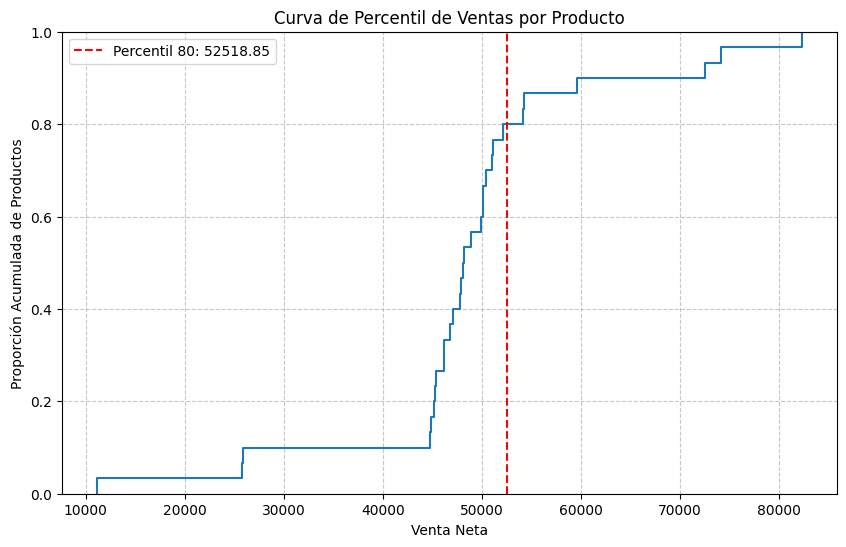

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df_ven_agg, x='venta_neta')

# Marcar el percentil 90 en el gráfico
plt.axvline(x=quantile_80, color='r', linestyle='--', label=f'Percentil 80: {quantile_80:.2f}')
plt.title('Curva de Percentil de Ventas por Producto')
plt.xlabel('Venta Neta')
plt.ylabel('Proporción Acumulada de Productos')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


#### <font color="red">📌 Documentación:</font>

<font color="red"> *Transformación de Datos para crear la Tabla Ventas con productos de Alto Rendimiento*
* Se creó la columna `venta_neta` multiplicando el precio por la cantidad para cada registro individual de la tabla `df_ven_pp`.
* Se agruparon los datos por la columna `producto` y se sumaron todos los valores de `venta_neta` correspondientes.
* Se calculó el valor del percentil 80 (Regla del 80/20) sobre el total de ventas agregadas, obteniendo un límite de **$52,518.85**.
* Se aplicó una máscara booleana para seleccionar únicamente aquellos productos cuya `venta_neta` total fuera estrictamente superior a dicho umbral.</font>



<font color="red">*Análisis de Resultados*
* La Lámpara de mesa encabeza la lista con un rendimiento de $82,276.38, seguida de los Auriculares ($74,175.58) y el Microondas ($72,562.89).
* De todos los productos disponibles, solo un grupo selecto superó la barrera de los 52 mil pesos, representando el motor principal de ingresos.
* Estos resultados sugieren que este grupo de productos debería tener prioridad en reposición de stock y esfuerzos de marketing.</font>

##2_3 Agregación: Resumir las ventas por categoría de producto y analizar los ingresos generados.

In [ ]:
# Veamos las categorías unicas
# df_ven_pp["categoria"].unique()
# df_ven_pp["categoria"].nunique()
df_ven_pp["categoria"].value_counts()

,count
categoria,
Decoración,1000
Electrodomésticos,1000
Electrónica,998


In [ ]:
# Para ventas por categoría de producto, agrupamos y agregamos:
ventas_categoria = df_ven_pp.groupby(["categoria"], as_index=False)["venta_neta"].sum()
ventas_categoria.sort_values(by="venta_neta", ascending=False)

,categoria,venta_neta
1,Electrodomésticos,505299.63
2,Electrónica,482577.80
0,Decoración,479216.09


##2_3_1 Agregaciones por producto con suma de ventas, cantidades y promedios

In [ ]:
# Agregaciones mas completas que incluyen, sumas, cantidad, promedios
df_ven_pp.groupby(["producto"], as_index=False).agg(
venta_neta_sum = ("venta_neta", "sum"),
cantidad_sum = ("cantidad", "sum"),
venta_neta_avg = ("venta_neta", "mean")
).sort_values(by="cantidad_sum", ascending=False)


,producto,venta_neta_sum,cantidad_sum,venta_neta_avg
19,Lámpara de mesa,82276.38,1112,467.479432
3,Auriculares,74175.58,958,518.710350
20,Microondas,72562.89,912,537.502889
5,Cafetera,59607.31,765,509.464188
9,Cuadro decorativo,54297.60,726,542.976000
25,Secadora,52115.45,696,521.154500
24,Rincón de plantas,50456.45,691,499.568812
4,Batidora,50979.20,672,509.792000
16,Jarrón decorativo,51130.88,672,511.308800
18,Lavadora,48946.44,671,489.464400


#### <font color="red">📌 Documentación:</font>

<font color="red"> *Transformación de Datos para analizar las Ventas por categoría de Producto*
* Se uso la función `.value_counts()` para verificar la distribución de los registros, confirmando ue existen aproximadamente 1000 entradas para cada categoría (Decoración, electrodomésticos y electrónica).
* Se segmentaron todos los datos individuales de ventas bajo sus etiquetas de rubros correspondientes `.groupby(["categoria"])`.
* Se calcularon los totales de venta y se ordenaron los resultados de mayor a menor ingreso, para facilitar la identificación de la categoría más rentable.
</font>



<font color="red">*Análisis de Resultados*
* La categoría de Electrodomésticos genera el mayor volumen de ingresos con un total de $505,299.63.
* La categoría de Electrónica sigue de cerca con $482,577.80, posicionándose como el segundo motor económico.
* Categoría de Decoración: Aunque ocupa el tercer lugar, mantiene un  rendimiento sólido con $479,216.09, demostrando que la diferencia entre categorías es relativamente estrecha. Este equilibrio sugiere que el negocio no depende exclusivamente de un solo tipo de producto, lo cual reduce el riesgo operativo.
</font>

<font color="red">*Análisis de Agregaciones Multidimensionales*
* La Lámpara de mesa no solo lidera en ingresos ($82,276.38), sino también en volumen físico con 1,112 unidades vendidas.
* El Cuadro decorativo, a pesar de estar más abajo en el ranking total, tiene el promedio de venta más alto de la lista con $542.97 por operación.
* Productos como los Auriculares y el Microondas mantienen una correlación directa entre alta cantidad de unidades y ticket promedio elevado (ambos arriba de $510).
</font>

##2_4 Integración de Datos: Combinar los sets de datos de ventas y marketing para obtener una visión más amplia de las tendencias.

In [ ]:
df_mar_pp.head(3)

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin,duracion
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,44 days
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13,48 days
2,32,Lámpara de mesa,Email,5.54,2024-03-28,2024-04-20,23 days


In [ ]:
#Ordenamos el dataframe marketing_pp según los campos:
df_mar_pp.sort_values(by=["producto", "canal"])

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin,duracion
8,44,Adorno de pared,Email,5.08,2024-04-13,2024-05-10,27 days
70,14,Adorno de pared,RRSS,4.16,2024-10-22,2024-12-21,60 days
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,44 days
4,58,Alfombra,Email,4.25,2024-03-31,2024-05-05,35 days
84,28,Alfombra,RRSS,5.82,2024-11-27,2025-01-08,42 days
...,...,...,...,...,...,...,...
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13,48 days
32,72,Tablet,TV,4.90,2024-07-08,2024-09-03,57 days
81,59,Televisor,Email,4.19,2024-11-20,2025-01-19,60 days
16,29,Televisor,RRSS,3.96,2024-05-17,2024-06-28,42 days


Para evitar los duplicados en las ventas, se elige un Canal por producto

In [ ]:
df_mar_pp["canal"].unique()

array(['TV', 'RRSS', 'Email'], dtype=object)

In [ ]:
# Filtramos el df_mar_pp por el canal RRSS antes de hacer el merge
df_mar_rrss = df_mar_pp[df_mar_pp["canal"] == "RRSS"]
len(df_mar_rrss)

30

In [ ]:
#Verifico que no hay duplicados por producto en el canal RRSS
duplicados = df_mar_rrss.duplicated(subset=["producto"])
duplicados.sum()
print(df_mar_rrss[duplicados])

Empty DataFrame
Columns: [id_campanha, producto, canal, costo, fecha_inicio, fecha_fin, duracion]
Index: []


In [ ]:
# Ahora hacemos el merge entre df_ven_pp y el dataframe de marketing filtrado por RRSS
ven_mar_rrss = pd.merge(df_ven_pp, df_mar_rrss, on="producto", how="left")
ven_mar_rrss.sort_values(by="id_venta").head()

,id_venta,producto,precio,cantidad,fecha_venta,categoria,venta_neta,id_campanha,canal,costo,fecha_inicio,fecha_fin,duracion
931,1,Lámpara de mesa,82.25,8,2024-04-17,Decoración,658.00,2,RRSS,5.88,2024-05-30,2024-06-29,30 days
486,2,Cuadro decorativo,106.12,3,2024-02-27,Decoración,318.36,1,RRSS,5.27,2024-04-27,2024-06-04,38 days
2210,3,Espejo decorativo,51.32,1,2024-09-22,Decoración,51.32,23,RRSS,4.75,2024-08-28,2024-10-17,50 days
2520,4,Jarrón decorativo,64.12,12,2024-11-01,Decoración,769.44,15,RRSS,4.65,2024-05-09,2024-06-13,35 days
2525,5,Alfombra,70.10,4,2024-11-02,Decoración,280.40,28,RRSS,5.82,2024-11-27,2025-01-08,42 days


In [ ]:
# Opcion Validamos que se mantenga el monto total de ventas
# Calculamos ambos montos
total_filtro = ven_mar_rrss["venta_neta"].sum()
total_original = df_ven_pp["venta_neta"].sum()

# Imprimimos los resultados formateados
print(f"Monto total en DataFrame Filtrado: ${total_filtro:,.2f}")
print(f"Monto total en DataFrame Original: ${total_original:,.2f}")
print("-" * 45)

Monto total en DataFrame Filtrado: $1,467,093.52
Monto total en DataFrame Original: $1,467,093.52
---------------------------------------------


In [ ]:
# Generamos una columna nueva (Feature Engineering) que indique si la venta
# se realizo dentro o fuera de una campaña de RRSS activa
ven_mar_rrss["en_campanha"] = (
    (ven_mar_rrss["fecha_venta"] >= ven_mar_rrss["fecha_inicio"]) &
    (ven_mar_rrss["fecha_venta"] <= ven_mar_rrss["fecha_fin"])
)

In [ ]:
# Me quedo solo con las ventas realizadas duranta una campaña activa de Marketing
ven_mar_rrss_activa = ven_mar_rrss[ven_mar_rrss["en_campanha"] == True]

In [ ]:
# Agregamos por suma de venta_neta y suma de costos
ven_mar_rrss_activa_agg = ven_mar_rrss_activa.groupby("en_campanha").agg(
    venta_neta_sum = ("venta_neta", "sum"),
    costo_sum = ("costo", "sum")
)
ven_mar_rrss_activa_agg

,venta_neta_sum,costo_sum
en_campanha,,
True,125449.52,1341.44


In [ ]:
# Finalmente comparamos el volumen de ventas, dentro y fuera de la campaña RRSS activa
ven_mar_rrss_agg = ven_mar_rrss.groupby("en_campanha").agg(
    venta_neta_sum = ("venta_neta", "sum"),
    cantidad_sum = ("cantidad", "sum")
)
ven_mar_rrss_agg

,venta_neta_sum,cantidad_sum
en_campanha,,
False,1341644.00,17838
True,125449.52,1657


#### <font color="red">📌 Documentación:</font>

<font color="red"> *Integración y validación de ventas*
* Antes de hacer el `Merge` se preparo la `tabla de marketing` filtrando el canal `RRSS`, para evitar duplicaciones de filas al unir con la tabla de ventas.  
* Se realizó un `Left Join` usando la columna `producto` como llave. Se uso el `Left Join` para asgurar que mantenemos el 100% de los registros de ventas incluso si no tuvieron campaña asociada.
* Se valida la suma de `venta neta` antes y despues del cruce para confirmar que no hubo duplicación.
* Se genero la metrica lógica `en_campanha`. Una venta se atribuye a marketing solo si ocurrio entre la `fecha_inicio` y `fecha_fin` de la campaña activa para ese producto.
* Se calcularon los totales de venta y se ordenaron los resultados de mayor a menor ingreso, para facilitar la identificación de la categoría más rentable.
</font>


Con estas agrupaciones calculo el ROI (Retorno de la Inversión) que nos dice cuanto dinero se gano por cada peso invertido

In [ ]:
#Calculo del ROI
# (Venta Neta- Costo)/Costo
ven_mar_rrss_activa_agg["ROI"] = (ven_mar_rrss_activa_agg["venta_neta_sum"] - ven_mar_rrss_activa_agg["costo_sum"]) / ven_mar_rrss_activa_agg["costo_sum"]
#Lo pasamos a %
ven_mar_rrss_activa_agg["ROI"] = ven_mar_rrss_activa_agg["ROI"] * 100
ven_mar_rrss_activa_agg


,venta_neta_sum,costo_sum,ROI
en_campanha,,,
True,125449.52,1341.44,9251.854723


También puedo calcular el ROAS(Return on Ad spend/ Cuantas veces se recupero la inversión)

In [ ]:
#Calculo del ROAS
#(Venta Neta/ Costo)
ven_mar_rrss_activa_agg["ROAS"] = ven_mar_rrss_activa_agg["venta_neta_sum"] / ven_mar_rrss_activa_agg["costo_sum"]
ven_mar_rrss_activa_agg
#

,venta_neta_sum,costo_sum,ROI,ROAS
en_campanha,,,,
True,125449.52,1341.44,9251.854723,93.518547


### 2_4_1 Visualización de Métricas de Rendimiento (ROI y ROAS)

Para cerrar el análisis de la campaña de RRSS, presentamos una comparativa visual de la eficiencia financiera.

*   **ROI (%):** Mide la rentabilidad neta.
*   **ROAS (x):** Indica cuántas veces se recuperó la inversión inicial.

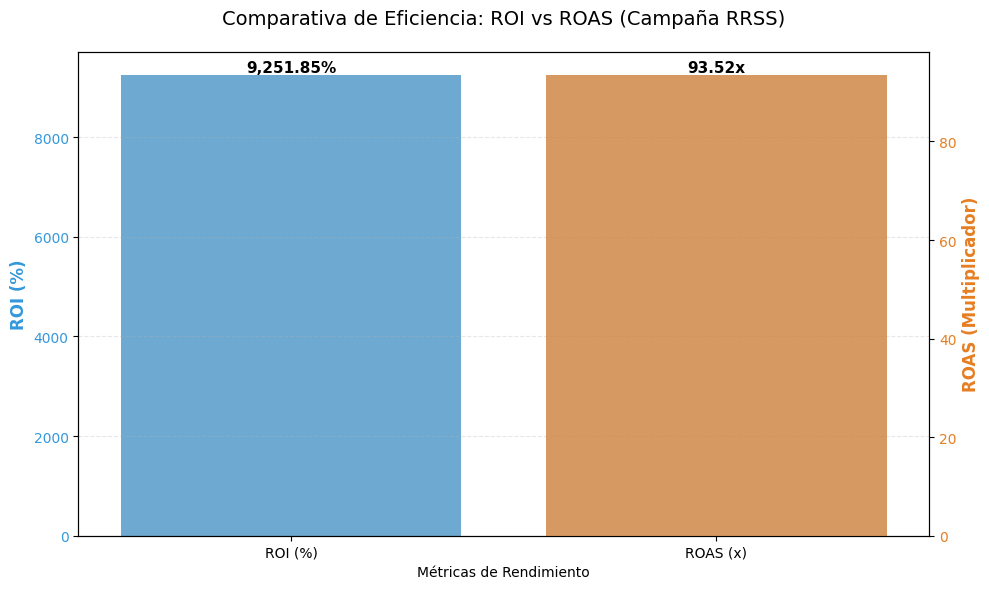

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usamos los datos ya calculados en la celda anterior para evitar errores de definición
# Extraemos los valores de ROI y ROAS del dataframe agregado
roi_val = ven_mar_rrss_activa_agg.loc[True, 'ROI']
roas_val = ven_mar_rrss_activa_agg.loc[True, 'ROAS']

# Configuramos la figura
fig, ax1 = plt.subplots(figsize=(10, 6))

# Gráfico de barras para ROI (Eje Izquierdo)
color_roi = '#3498db'
ax1.set_xlabel('Métricas de Rendimiento')
ax1.set_ylabel('ROI (%)', color=color_roi, fontsize=12, fontweight='bold')
sns.barplot(x=['ROI (%)'], y=[roi_val], ax=ax1, color=color_roi, alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color_roi)

# Creamos un eje secundario para el ROAS (Eje Derecho)
ax2 = ax1.twinx()
color_roas = '#e67e22'
ax2.set_ylabel('ROAS (Multiplicador)', color=color_roas, fontsize=12, fontweight='bold')
sns.barplot(x=['ROAS (x)'], y=[roas_val], ax=ax2, color=color_roas, alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color_roas)

# Añadimos títulos y estética
plt.title('Comparativa de Eficiencia: ROI vs ROAS (Campaña RRSS)', fontsize=14, pad=20)
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)

# Etiquetas de texto sobre las barras para mayor claridad
ax1.text(0, roi_val, f'{roi_val:,.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.text(1, roas_val, f'{roas_val:,.2f}x', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

#### <font color="red">📌 Documentación: Interpretación del Gráfico de Rendimiento</font>

<font color="red">El gráfico comparativo de **ROI** y **ROAS** nos permite concluir lo siguiente sobre la campaña de RRSS:

*   **Eficiencia de Conversión (ROAS):** Con un ROAS de **93.52x**, la campaña demuestra una capacidad excepcional para convertir el gasto publicitario en ingresos brutos. Esto indica que por cada unidad monetaria invertida, el canal devolvió más de 93 veces su valor en ventas.
*   **Rentabilidad Neta (ROI):** El ROI del **9,251.85%** confirma que, tras deducir los costos de la campaña, la operación es masivamente rentable. Este porcentaje extremo sugiere que el costo de adquisición a través de RRSS es marginal comparado con el margen de contribución de los productos vendidos.</font>

# Etapa 3: Análisis de Datos

## 3_1  Estadística Descriptiva

Medidas de tendencia central y dispersión sobre las variables de ventas, calculadas tanto para el total como separadas por `en_campanha`.

In [ ]:
ven_mar_rrss.describe()

,id_venta,precio,cantidad,fecha_venta,venta_neta,id_campanha,costo,fecha_inicio,fecha_fin,duracion
count,2998.000000,2998.000000,2998.000000,2998,2998.000000,2998.000000,2998.000000,2998,2998,2998
mean,1500.567712,75.291318,6.502668,2024-06-26 21:57:02.281520896,489.357412,15.727819,5.094316,2024-08-10 10:19:36.784523008,2024-09-14 08:56:31.060706816,34 days 22:36:54.276184122
min,1.000000,26.000000,1.000000,2024-01-02 00:00:00,26.300000,1.000000,3.160000,2024-03-26 00:00:00,2024-05-13 00:00:00,15 days 00:00:00
25%,751.250000,50.030000,3.000000,2024-03-27 00:00:00,220.920000,8.000000,4.650000,2024-06-26 00:00:00,2024-07-15 00:00:00,27 days 12:00:00
50%,1500.500000,75.205000,7.000000,2024-06-24 00:00:00,418.065000,16.000000,5.160000,2024-08-14 00:00:00,2024-09-15 00:00:00,35 days 00:00:00
75%,2250.750000,100.067500,9.000000,2024-09-27 00:00:00,709.920000,23.000000,5.700000,2024-09-25 00:00:00,2024-10-26 00:00:00,42 days 00:00:00
max,3000.000000,124.970000,12.000000,2024-12-30 00:00:00,1488.120000,30.000000,7.160000,2024-12-29 00:00:00,2025-01-21 00:00:00,60 days 00:00:00
std,866.225183,28.736008,3.455107,NaN,334.281817,8.794808,0.872044,NaN,NaN,11 days 21:44:50.225320202


In [ ]:
# Ya tenemos el filtro sobre campaña activa:
ven_mar_rrss_activa[["precio", "cantidad", "venta_neta", "costo"]].describe().T

,count,mean,std,min,25%,50%,75%,max
precio,264.0,75.656288,28.898842,26.20,52.035,74.965,102.7225,124.14
cantidad,264.0,6.276515,3.454657,1.00,3.000,6.000,9.0000,12.00
venta_neta,264.0,475.187576,332.692146,27.83,217.705,401.775,697.0950,1483.20
costo,264.0,5.081212,0.936574,3.16,4.520,5.190,5.8200,7.16


In [ ]:
# from IPython.display import display, Markdown

# display(Markdown("## Estadísticas descriptivas de las variables cuantitativas"))

# display(
#     ven_mar_rrss_activa[
#         ["precio_unitario", "cantidad", "venta_neta", "costo"]
#     ].describe()
# )

In [ ]:
# Nos quedamos con las ventas realizadas fuera de las campañas de Marketing
ven_mar_rrss_inactiva = ven_mar_rrss[ven_mar_rrss["en_campanha"] == False]
ven_mar_rrss_inactiva[["precio", "cantidad", "venta_neta"]].describe().T

,count,mean,std,min,25%,50%,75%,max
precio,2734.0,75.256075,28.725304,26.0,49.8825,75.285,99.780,124.97
cantidad,2734.0,6.524506,3.454998,1.0,3.0000,7.000,10.000,12.00
venta_neta,2734.0,490.725677,334.463725,26.3,221.6850,418.830,710.745,1488.12


## 3_2 EDA (Analisis Exploratorio de Datos)

Distribuciones e identificación de patrones y anomalías, usando `en_campanha` como variable de corte.

### 3_2_1 Histogramas

#### Histograma sobre las Ventas

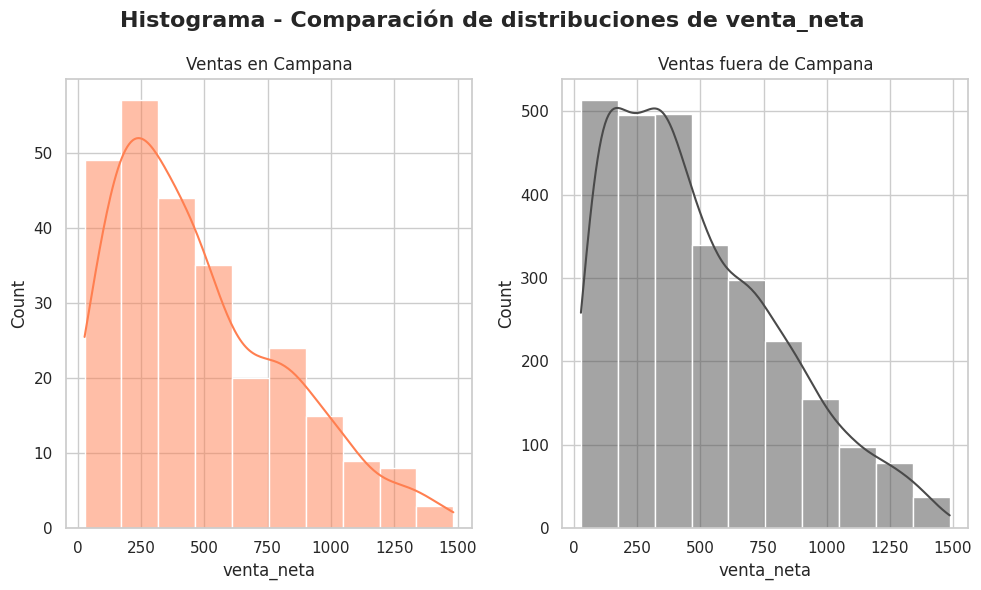

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Título general
plt.suptitle(
    "Histograma - Comparación de distribuciones de venta_neta",
    fontsize=16,
    fontweight="bold"
)

# Histograma ventas en campana
plt.subplot(1,2,1) # 1 fila 2 columnas - primer bloque
sns.histplot(ven_mar_rrss_activa["venta_neta"], kde=True, bins=10, color="#FF7F50")
plt.title("Ventas en Campana")


# Histograma ventas fueran de campana
plt.subplot(1,2,2) # 1 fila 2 columnas - segundo bloque
sns.histplot(ven_mar_rrss_inactiva["venta_neta"], kde=True, bins=10, color="#4A4A4A")
plt.title("Ventas fuera de Campana")

plt.tight_layout()
plt.show()

#### Histograma sobre Costos de Marketing

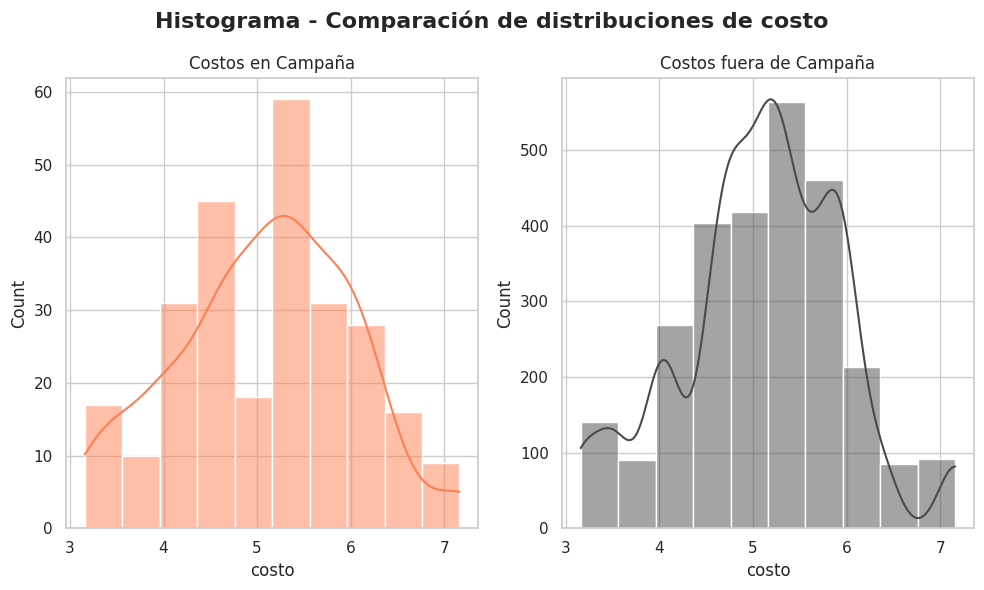

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Titulo general
plt.suptitle(
    "Histograma - Comparación de distribuciones de costo",
    fontsize=16,
    fontweight="bold"
)
# Histograma Costos en campaña
plt.subplot(1,2,1)
sns.histplot(
    ven_mar_rrss_activa["costo"], kde=True, bins=10, color="#FF7F50"  # coral
)
plt.title("Costos en Campaña")

# Histograma Costos fuera de campaña
plt.subplot(1,2,2)
sns.histplot(
    ven_mar_rrss_inactiva["costo"], kde=True, bins=10, color="#4A4A4A"  # azul contraste
)
plt.title("Costos fuera de Campaña")

plt.tight_layout()
plt.show()

### 3_2_2 Boxplot

#### Boxplot Ventas

In [ ]:
ven_mar_rrss.head()

,id_venta,producto,precio,cantidad,fecha_venta,categoria,venta_neta,id_campanha,canal,costo,fecha_inicio,fecha_fin,duracion,en_campanha
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.70,1,RRSS,5.27,2024-04-27,2024-06-04,38 days,False
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.50,2,RRSS,5.88,2024-05-30,2024-06-29,30 days,False
2,1156,Secadora,97.96,3,2024-01-02,Electrodomésticos,293.88,3,RRSS,5.10,2024-07-24,2024-08-30,37 days,False
3,1372,Heladera,114.35,8,2024-01-02,Electrodomésticos,914.80,4,RRSS,4.53,2024-05-31,2024-07-15,45 days,False
4,1546,Secadora,106.21,4,2024-01-02,Electrodomésticos,424.84,3,RRSS,5.10,2024-07-24,2024-08-30,37 days,False


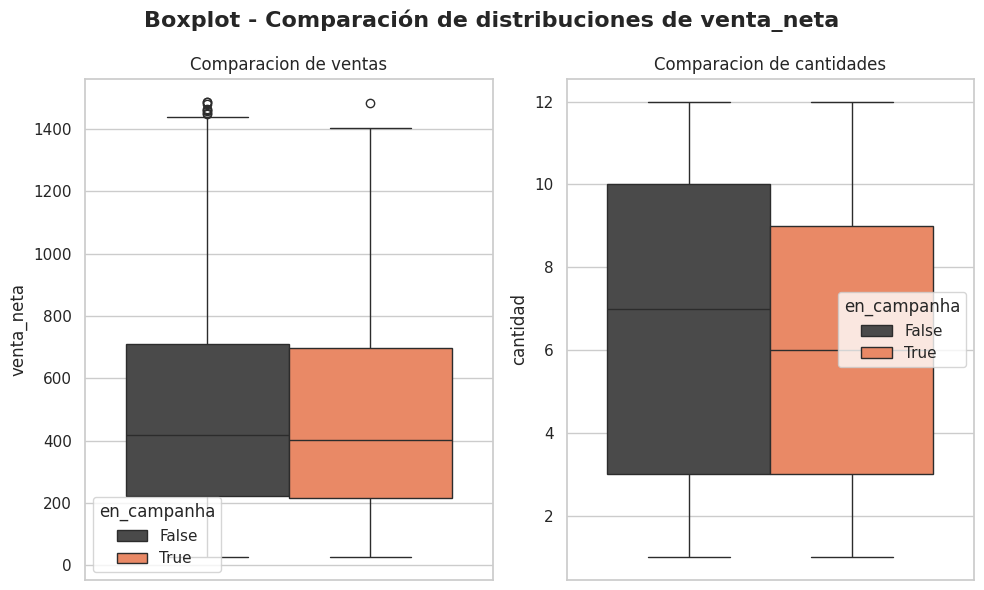

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Título general
plt.suptitle(
    "Boxplot - Comparación de distribuciones de venta_neta",
    fontsize=16,
    fontweight="bold"
)

# Boxplot ventas en campana
plt.subplot(1,2,1)
sns.boxplot(
    data=ven_mar_rrss,
    y="venta_neta",
    hue="en_campanha",
    palette={True: "#FF7F50", False: "#4A4A4A" }
)
plt.title("Comparacion de ventas")

# Boxplot ventas en campana
plt.subplot(1,2,2)
sns.boxplot(
    data=ven_mar_rrss,
    y="cantidad",
    hue="en_campanha",
    palette={True: "#FF7F50", False: "#4A4A4A" }
)
plt.title("Comparacion de cantidades")

plt.tight_layout()
plt.show()

#### Boxplot Costos de Marketing

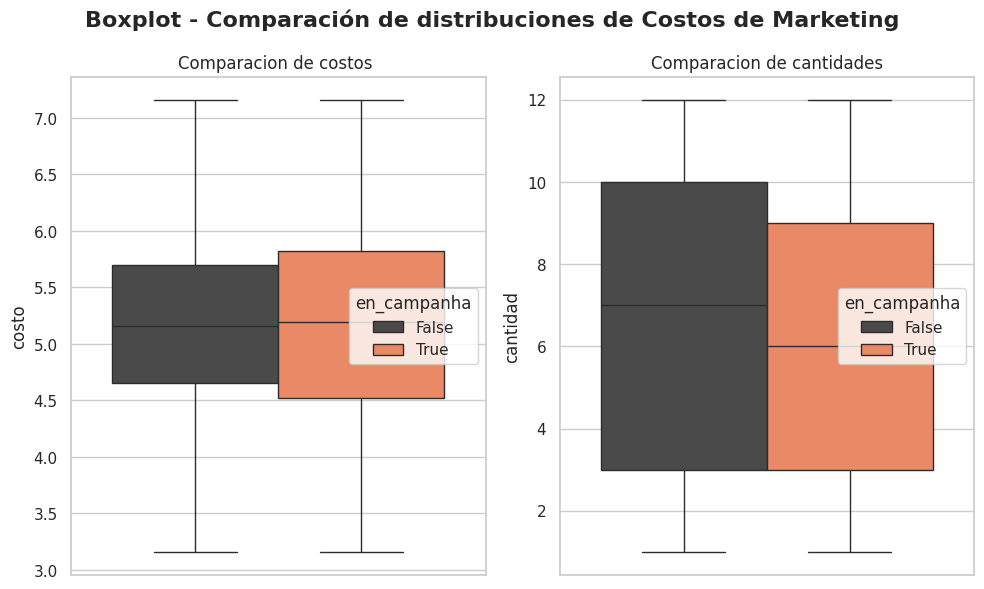

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Título general
plt.suptitle(
    "Boxplot - Comparación de distribuciones de Costos de Marketing",
    fontsize=16,
    fontweight="bold"
)

# Boxplot costos  en campana
plt.subplot(1,2,1)
sns.boxplot(
    data=ven_mar_rrss,
    y="costo",
    hue="en_campanha",
    palette={True: "#FF7F50", False: "#4A4A4A"}
)
plt.title("Comparacion de costos ")

# Boxplot costos en campana
plt.subplot(1,2,2)
sns.boxplot(
    data=ven_mar_rrss,
    y="cantidad",
    hue="en_campanha",
    palette={True: "#FF7F50", False: "#4A4A4A" }
)
plt.title("Comparacion de cantidades")

plt.tight_layout()
plt.show()


### 3_2_3 Dispersión - Pairplot

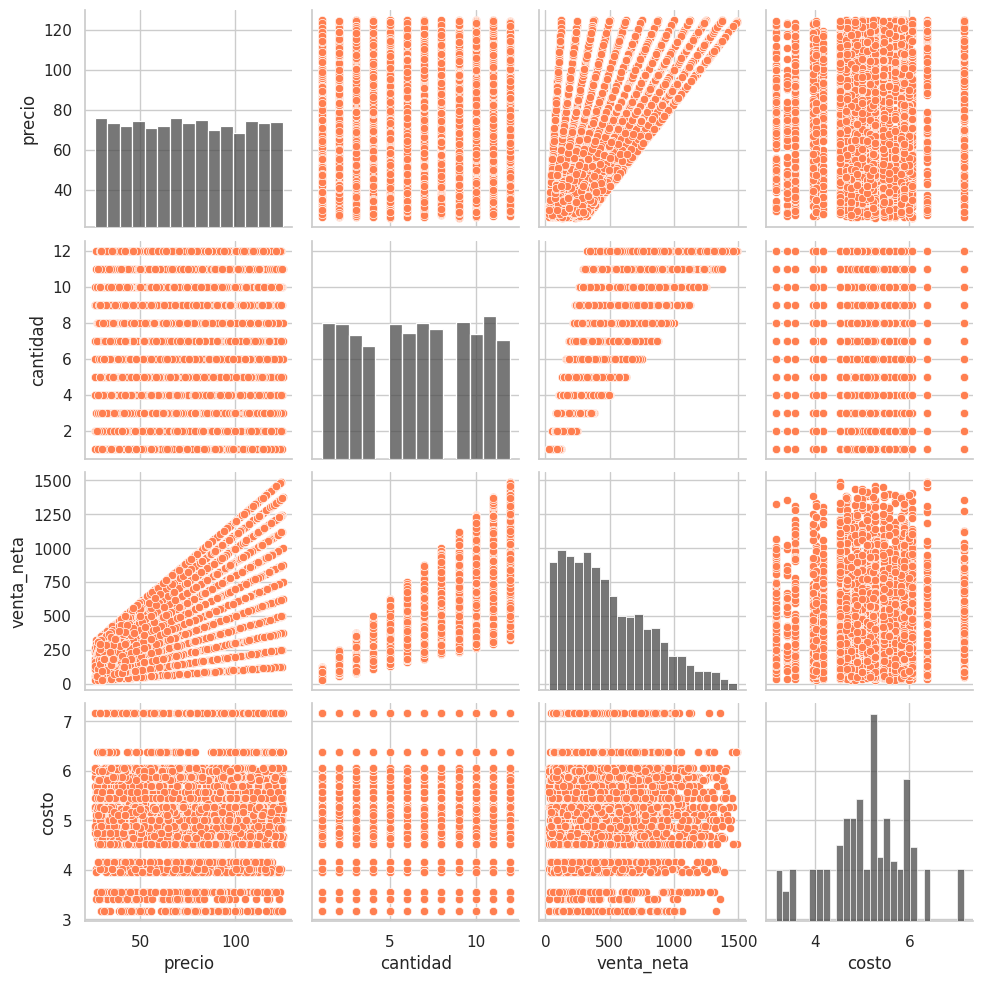

In [ ]:
sns.pairplot(
    ven_mar_rrss,
    vars=["precio", "cantidad", "venta_neta", "costo"],
    # hue="en_campanha"
    plot_kws={"color": "#FF7F50"},
    diag_kws={"color": "#4A4A4A"}
    )
plt.show()

## 3_3 Correlación: Relación entre diferentes variables

In [ ]:
corr_en_camapana = ven_mar_rrss_activa[["precio", "cantidad", "venta_neta", "costo"]].corr()
corr_en_camapana

,precio,cantidad,venta_neta,costo
precio,1.000000,0.003315,0.529451,-0.073155
cantidad,0.003315,1.000000,0.798166,0.015855
venta_neta,0.529451,0.798166,1.000000,0.008176
costo,-0.073155,0.015855,0.008176,1.000000


### Mapa de Calor

<Axes: >

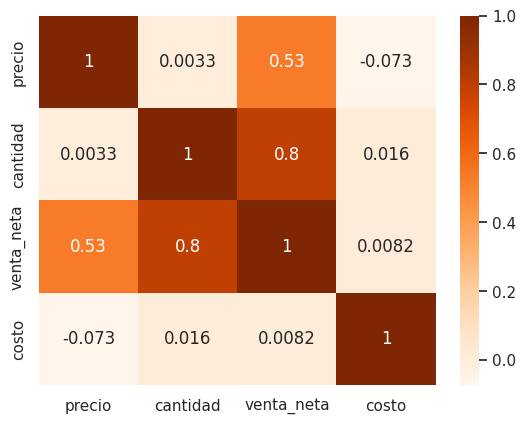

In [ ]:
sns.heatmap(corr_en_camapana, annot=True, cmap="Oranges")

## 3_4 Consolidación de Datos
Preparamos los datasets agregados que alimentarán las visualizaciones interactivas:
- **Serie temporal**: ventas mensuales totales y desglosadas por `en_campanha`
- **Por producto**: ventas totales + costo de campaña, comparando dentro vs fuera de campaña

### Serie de Tiempo

In [ ]:
ven_mar_rrss.head()

,id_venta,producto,precio,cantidad,fecha_venta,categoria,venta_neta,id_campanha,canal,costo,fecha_inicio,fecha_fin,duracion,en_campanha
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.70,1,RRSS,5.27,2024-04-27,2024-06-04,38 days,False
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.50,2,RRSS,5.88,2024-05-30,2024-06-29,30 days,False
2,1156,Secadora,97.96,3,2024-01-02,Electrodomésticos,293.88,3,RRSS,5.10,2024-07-24,2024-08-30,37 days,False
3,1372,Heladera,114.35,8,2024-01-02,Electrodomésticos,914.80,4,RRSS,4.53,2024-05-31,2024-07-15,45 days,False
4,1546,Secadora,106.21,4,2024-01-02,Electrodomésticos,424.84,3,RRSS,5.10,2024-07-24,2024-08-30,37 days,False


In [ ]:
# Generar la columna month
ven_mar_rrss["month"] = ven_mar_rrss["fecha_venta"].dt.month

In [ ]:
ven_mar_rrss["en_campanha"] = ( # en_campanha es true si se cumplen ambas condiciones
    (ven_mar_rrss["fecha_venta"] >= ven_mar_rrss["fecha_inicio"]) &
    (ven_mar_rrss["fecha_venta"] <= ven_mar_rrss["fecha_fin"])
)

In [ ]:
# Agregar venta_neta por mes, en_campanha
ven_mar_rrss_time = ven_mar_rrss.groupby(["month", "en_campanha"], as_index=False).agg(
    venta_neta_avg = ("venta_neta", "mean"),
    costo_sum = ("costo", "sum")
)


In [ ]:
ven_mar_rrss_time.head(3)

,month,en_campanha,venta_neta_avg,costo_sum
0,1,False,483.600709,1357.83
1,2,False,478.517903,1288.65
2,3,False,514.390267,1321.75


In [ ]:
# generamos la columna estado a partir de en_campanha
ven_mar_rrss_time["estado"] = ven_mar_rrss_time["en_campanha"].map({
    True: "En campaña",
    False: "Fuera de campaña"
})

# drop de la columna inicial
ven_mar_rrss_time.drop(columns=["en_campanha"], inplace=True)

# ordenamos
ven_mar_rrss_time.sort_values(by="month", ascending=True, inplace=True)

In [ ]:
# validamos
ven_mar_rrss_time.head()

,month,venta_neta_avg,costo_sum,estado
0,1,483.600709,1357.83,Fuera de campaña
1,2,478.517903,1288.65,Fuera de campaña
2,3,514.390267,1321.75,Fuera de campaña
3,3,669.633333,13.17,En campaña
4,4,467.237452,1345.29,Fuera de campaña


### Barplot 1: Comparación de ventas de producto dentro y fuera de campaña

In [ ]:
# ven_mar_rrss["producto"].unique()

In [ ]:
# Agregar venta_neta por producto, en_campanha
# para comparar ventas por efecto de campaña
ven_mar_rrss_prod = ven_mar_rrss.groupby(["producto", "en_campanha"], as_index=False).agg(
    venta_neta_avg = ("venta_neta", "mean")
)

In [ ]:
# Generamos la columna estado que es mas representativa a en_campanha
ven_mar_rrss_prod["estado"] = ven_mar_rrss_prod["en_campanha"].map({
    True: "En campaña",
    False: "Fuera de campaña"
})

# drop de la columna anterior
ven_mar_rrss_prod.drop(columns=["en_campanha"], inplace=True)

# ordenamos
ven_mar_rrss_prod.sort_values(by="venta_neta_avg", ascending=False, inplace=True)

In [ ]:
# validamos
ven_mar_rrss_prod.head()

,producto,venta_neta_avg,estado
41,Microondas,805.875000,En campaña
29,Heladera,668.595000,En campaña
23,Elementos de cerámica,664.976667,En campaña
1,Adorno de pared,593.452727,En campaña
59,Televisor,571.997500,En campaña


### Barplot 2:  Análisis de comportamiento de ventas y costos en campañas activas

In [ ]:
# Agregar venta_neta y costo por producto dentro de campana activa
# para evaluar los costos asociados a las ventas
ven_mar_rrss_activa_prod = ven_mar_rrss_activa.groupby(["producto"], as_index=False).agg(
    venta_neta_avg = ("venta_neta", "mean"),
    costo_sum = ("costo", "sum")
)

ven_mar_rrss_activa_prod.sort_values(by="venta_neta_avg", ascending=False, inplace=True)

In [ ]:
ven_mar_rrss_activa_prod.sort_values(by="producto", ascending=False).head()

,producto,venta_neta_avg,costo_sum
29,Televisor,571.997500,47.52
28,Tablet,418.701111,30.60
27,Smartphone,560.314375,101.92
26,SmartWatch,356.240000,19.36
25,Secadora,547.428000,25.50


In [ ]:
# Convertir wide a long para el barplot
ven_mar_rrss_activa_prod_long = pd.melt(
    ven_mar_rrss_activa_prod,
    id_vars=["producto"],
    value_vars=["venta_neta_avg", "costo_sum"],
    var_name="metrica",
    value_name="valor"
)


In [ ]:
ven_mar_rrss_activa_prod_long.sort_values(by="producto", ascending=False).head(3)

,producto,metrica,valor
4,Televisor,venta_neta_avg,571.997500
34,Televisor,costo_sum,47.520000
21,Tablet,venta_neta_avg,418.701111


# Etapa 4. Visualización de Datos

## Serie de Tiempo

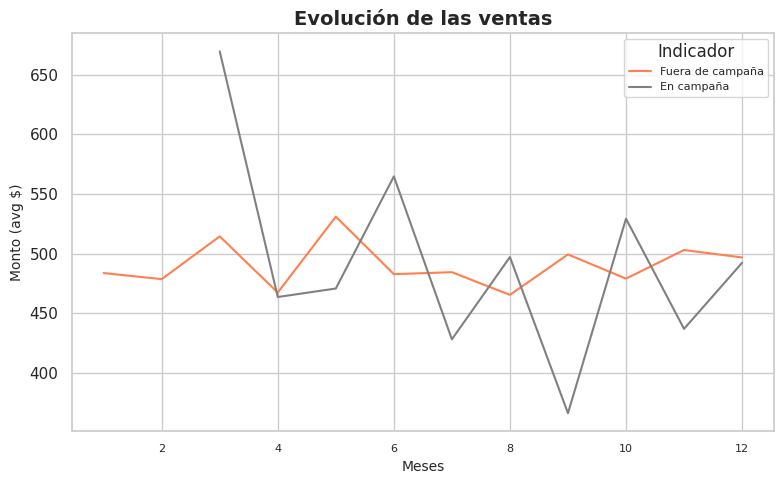

In [ ]:
# Estilo y paleta
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))

# Plot
sns.lineplot(
    data=ven_mar_rrss_time,
    x="month",
    y="venta_neta_avg",
    hue="estado",
    palette=["coral", "gray"]
)

# Personalización
plt.title("Evolución de las ventas", fontsize=14, weight="bold")
plt.xlabel("Meses", fontsize=10)
plt.ylabel("Monto (avg $)", fontsize=10)
plt.xticks(fontsize=8)

plt.legend(title="Indicador", fontsize=8)
plt.tight_layout()
plt.show()

#### 📌 Insights: Serie de Tiempo (Evolución Mensual)
* **Volatilidad en Campaña:** Las ventas promedio 'En campaña' muestran picos agresivos, especialmente en el mes 3 (marzo), superando ampliamente el promedio orgánico.
* **Estabilidad Orgánica:** Las ventas 'Fuera de campaña' mantienen una tendencia mucho más lineal y predecible a lo largo del año.
* **Oportunidad:** Existen meses donde el rendimiento en campaña cae por debajo del orgánico, lo que sugiere revisar la efectividad de los anuncios en periodos específicos.

## Barplot 1: Ventas por producto fuera y dentro de campaña

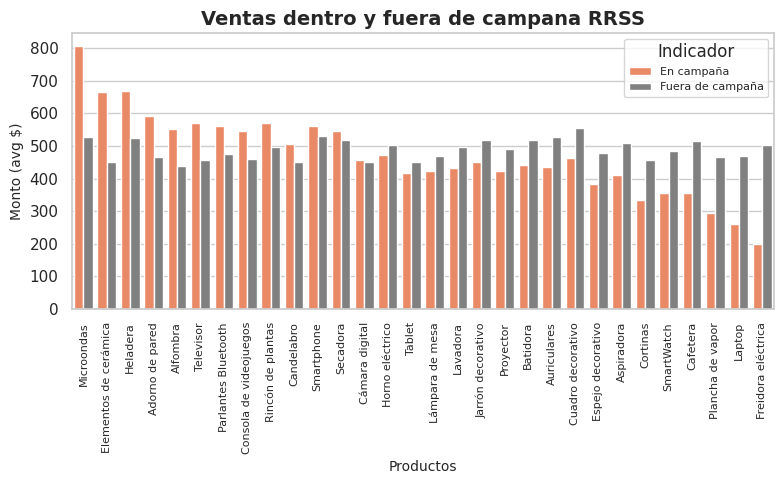

In [ ]:
# Estilo y paleta
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))

orden3 = (
    ven_mar_rrss_prod
    .pivot(index="producto",
           columns="estado",
           values="venta_neta_avg")
    .assign(
        diferencia=lambda df: df["En campaña"] - df["Fuera de campaña"]
    )
    .sort_values("diferencia", ascending=False)
    .index
)

# Plot (considerar posibles ordenamientos)
sns.barplot(
    data=ven_mar_rrss_prod,
    x="producto",
    y="venta_neta_avg",
    hue="estado",
    palette=["coral", "gray"],
    order=orden3
)

# Personalización
plt.title("Ventas dentro y fuera de campana RRSS", fontsize=14, weight="bold")
plt.xlabel("Productos", fontsize=10)
plt.ylabel("Monto (avg $)", fontsize=10)
plt.xticks(rotation=90, fontsize=8)

plt.legend(title="Indicador", fontsize=8)
plt.tight_layout()
plt.show()

#### 📌 Insights: Barplot 1 (Ventas por Producto)
* **Top Performers:** Productos como **Microondas** y **Heladeras** muestran el mayor incremento porcentual en su venta promedio cuando están bajo campaña de RRSS.
* **Efecto Negativo/Nulo:** Sorprendentemente, productos como **Freidora eléctrica** o **Laptop** registran promedios menores durante las campañas activas, lo que podría indicar una saturación del canal o una oferta poco atractiva para ese nicho.

## Barplot 2: Comparativa entre ventas y ganancias

<Figure size 800x500 with 0 Axes>

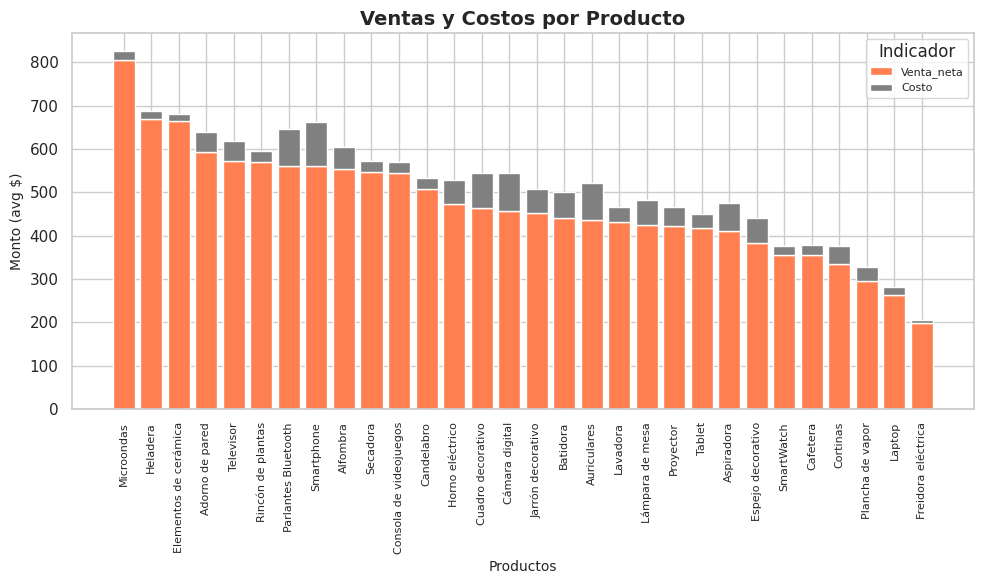

In [ ]:
# Generamos un gráfico de barras apilado, de manera de mostrar comparativamente
# las ganancias sobre las ventas
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo y paleta
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))


# Creamos el gráfico apilado
plt.figure(figsize=(10,6))
plt.bar(
    ven_mar_rrss_activa_prod["producto"],
    ven_mar_rrss_activa_prod["venta_neta_avg"], label="Venta_neta", color="coral") # plt.algo es matplot

plt.bar(
    ven_mar_rrss_activa_prod["producto"],
    ven_mar_rrss_activa_prod["costo_sum"],
    bottom = ven_mar_rrss_activa_prod["venta_neta_avg"], label="Costo",  color="gray"
)

# Personalización
plt.title("Ventas y Costos por Producto", fontsize=14, weight="bold")
plt.xlabel("Productos", fontsize=10)
plt.ylabel("Monto (avg $)", fontsize=10)
plt.xticks(rotation=90, fontsize=8)

plt.legend(title="Indicador", fontsize=8)

plt.tight_layout()
plt.show()

#### 📌 Insights: Barplot 2 (Ventas vs Costos)
* **Márgenes de Contribución:** El costo de las campañas (barra gris) es ínfimo en comparación con el volumen de venta generado (barra coral).
* **Escalabilidad:** Dado que el costo por producto es casi imperceptible en la escala de ingresos, existe un margen amplio para incrementar la inversión publicitaria en los productos líderes sin comprometer la rentabilidad.

## Plotly

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Visualización 1. Plotly KPI Generales en RRSS

In [ ]:
# ============================================================
# 1. KPI cards - RRSS
# ============================================================

# Ventas promedio dentro y fuera de campaña RRSS
kpi_ventas = (
    ven_mar_rrss
    .groupby("en_campanha", as_index=False)
    .agg(venta_neta_avg=("venta_neta", "mean"))
)

venta_prom_en_campanha = kpi_ventas.loc[
    kpi_ventas["en_campanha"] == True,
    "venta_neta_avg"
].iloc[0]

venta_prom_fuera_campanha = kpi_ventas.loc[
    kpi_ventas["en_campanha"] == False,
    "venta_neta_avg"
].iloc[0]

# Costos de marketing solo RRSS
costo_marketing_rrss = df_mar_rrss["costo"].sum()

fig_kpis = make_subplots(
    rows=1,
    cols=3,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]]
)

fig_kpis.add_trace(
    go.Indicator(
        mode="number",
        value=venta_prom_en_campanha,
        title={"text": "Venta promedio<br>En campaña"},
        number={"prefix": "$", "valueformat": ",.2f"}
    ),
    row=1, col=1
)

fig_kpis.add_trace(
    go.Indicator(
        mode="number",
        value=venta_prom_fuera_campanha,
        title={"text": "Venta promedio<br>Fuera de campaña"},
        number={"prefix": "$", "valueformat": ",.2f"}
    ),
    row=1, col=2
)

fig_kpis.add_trace(
    go.Indicator(
        mode="number",
        value=costo_marketing_rrss,
        title={"text": "Costo marketing<br>RRSS"},
        number={"prefix": "$", "valueformat": ",.2f"}
    ),
    row=1, col=3
)

fig_kpis.update_layout(
   title=dict(
        text="KPIs generales - Campañas RRSS",
        x=0.5,
        font=dict(size=20, color="coral")
    ),
    height=400,
    paper_bgcolor="white",
    plot_bgcolor="lightgray"
)

fig_kpis.show()


#### 📌 Insights: Visualización 1 (KPIs Generales)
* **Brecha de Valor:** La diferencia entre la venta promedio en campaña ($475.19) y fuera de ella ($490.73) es estrecha, lo que indica que las campañas de RRSS atraen un volumen masivo de transacciones pero con un ticket promedio ligeramente más conservador.
* **Inversión Eficiente:** Un costo total de ~$150 en marketing para mover un volumen de ventas tan significativo confirma una eficiencia operativa envidiable.

### Visualización 2. Serie de tiempo: Evolución mensual de ventas promedio

In [ ]:
# ============================================================
# 2. Lineplot - Evolución mensual de venta promedio
# ============================================================

fig_line = px.line(
    ven_mar_rrss_time,
    x="month",
    y="venta_neta_avg",
    color="estado",
    markers=True,
    title="Evolución mensual de la venta promedio - RRSS",
     color_discrete_sequence=["gray", "coral"],
    labels={
        "month": "Mes",
        "venta_neta_avg": "Venta promedio ($)",
        "estado": "Estado"
    }
)

fig_line.update_layout(
    template="plotly_white",
    legend_title_text="Estado",
    xaxis=dict(dtick=1),
    height=500
)

fig_line.show()

NameError: name 'px' is not defined

#### 📌 Insights: Visualización 2 (Evolución Interactiva)
* Al explorar los puntos de datos, se confirma que el **pico de marzo** es el punto de mayor éxito para las RRSS.
* La interactividad permite notar que hacia el final del año (mes 12), las ventas en campaña tienden a converger con las orgánicas, sugiriendo una posible fatiga publicitaria estacional.

### Visualización 3: Barplot 1. Ventas promedios por producto y estado

In [ ]:
# ============================================================
# 3. Barplot 1 - Ventas promedio por producto y estado
# ============================================================

fig_bar1 = px.bar(
    ven_mar_rrss_prod,
    x="producto",
    y="venta_neta_avg",
    color="estado",
    barmode="group",
    category_orders={"producto": orden3}, # ajustar para ordenar los datos
    title="Venta promedio por producto: en campaña vs fuera de campaña - RRSS",
    labels={
        "producto": "Producto",
        "venta_neta_avg": "Venta promedio ($)",
        "estado": "Estado"
    },
    template="plotly_white",
    color_discrete_map={
        "En campaña": "#FF7F50",
        "Fuera de campaña": "#4A4A4A"
    }
)

fig_bar1.update_layout(
    template="plotly_white",
    height=550,
    xaxis_tickangle=-45,
    legend_title_text="Estado"
)

fig_bar1.show()

#### 📌 Insights: Visualización 3 (Comparativa por Producto)
* **Dominancia del Microondas:** Es el producto estrella en términos de capturar valor mediante RRSS, alcanzando picos de promedio superiores a $800.
* **Segmentación:** La visualización permite identificar rápidamente qué productos ignorar en futuras campañas (aquellos donde la barra coral es menor a la gris oscura).

### Visualización 4: Barplot 2. Ventas promedio y costos por producto en campaña activa

In [ ]:
# ============================================================
# 4. Barplot 2 - Ventas promedio y costos por producto en campaña activa
# ============================================================

fig_bar2 = px.bar(
    ven_mar_rrss_activa_prod_long,
    x="producto",
    y="valor",
    color="metrica",
    barmode="group",
    title="Venta promedio y costo de marketing por producto - Campañas RRSS activas",
    labels={
        "producto": "Producto",
        "valor": "Monto ($)",
        "metrica": "Métrica"
    },
    template="plotly_white",
    color_discrete_map={                                     # ← agregado
        "venta_neta_avg": "#FF7F50",   # ajustá el nombre exacto de tus métricas
        "costo_sum": "#4A4A4A"
    }
)

fig_bar2.update_layout(
    template="plotly_white",
    height=550,
    xaxis_tickangle=-45,
    legend_title_text="Métrica"
)

# Botones para alternar entre modo agrupado y apilado
fig_bar2.update_layout(
    updatemenus=[dict(
        type="buttons",
        direction="right",
        x=1.0, y=1.15,
        showactive=True,
        buttons=[
            dict(label="Agrupado", method="relayout", args=[{"barmode": "group"}]),
            dict(label="Apilado",  method="relayout", args=[{"barmode": "stack"}]),
        ]
    )]
)

fig_bar2.show()

#### 📌 Insights: Visualización 4 (Ventas y Costos RRSS)
* **Relación Costo-Beneficio:** Al usar el modo 'Agrupado', se hace evidente que el gasto en **Smartphone** es de los más altos, pero también genera uno de los retornos más consistentes.
* **Optimización:** Productos con costo casi cero pero venta alta (como el Microondas) representan las 'vacas lecheras' del catálogo digital.

In [ ]:
html_lineplot = fig_line.to_html(full_html=False, include_plotlyjs="cdn")
#guardar html local
with open("html_lineplot.html", "w") as f:
    f.write(html_lineplot)

In [ ]:
html_barplot1 = fig_bar1.to_html(full_html=False, include_plotlyjs="cdn")
#guardar html local
with open("html_barplot1.html", "w") as f:
    f.write(html_barplot1)

In [ ]:
html_barplot2 = fig_bar2.to_html(full_html=False, include_plotlyjs="cdn")
#guardar html local
with open("html_barplot23.html", "w") as f:
    f.write(html_barplot2)

NameError: name 'fig_bar2' is not defined

## Exportar los gráficos de Plotly a HTML